---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 2. Електронно-дірковий (p-n) перехід</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Утворення p-n переходу, різкий і плавний переходи</li>
  <li>Рівноважний стан: дифузія, дрейф, контактна різниця потенціалів</li>
  <li>Розподіл заряду, поля й потенціалу; ширина збідненого шару</li>
  <li>p-n перехід під прямою і зворотною напругою, квазірівні Фермі</li>
  <li>Бар'єрна та дифузійна ємності, варикап</li>
  <li>Контакт метал–напівпровідник: бар'єр Шотки та омічний контакт</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 2 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Утворення p-n переходу](#pn-formation)
* [Рівноважний стан p-n переходу](#pn-equilibrium)
    * [Розподіл заряду, поля, потенціалу та зонна діаграма](#pn-profiles)
    * [Ширина збідненого шару](#pn-width)
* [p-n перехід під зовнішньою напругою](#pn-bias)
    * [🔬 Інтерактивно: перехід при зміщенні — заряд, поле, зонна діаграма](#pn-bias-interactive)
* [Ємності p-n переходу](#pn-capacitance)
    * [⚙️ PySpice: вольт-фарадна характеристика діодів](#spice-cv)
    * [⚙️ PySpice: коливальний контур, який перестроюється варикапом](#spice-varicap)
* [Контакт метал–напівпровідник](#ms-contact)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

eps_Si = 11.7*eps0*1e-2      # Ф/см, діелектрична проникність кремнію
ni_Si = 9.65e9               # см^-3, власна концентрація Si при 300 К

def pn_junction(Na, Nd, U=0.0, T=300.0, npts=2000):
    """Різкий p-n перехід у наближенні повного збіднення (p-область — x<0, n-область — x>0).
    Повертає словник з координатою (мкм), зарядом, полем, потенціалом і параметрами переходу."""
    phik = phi_T(T)*np.log(Na*Nd/ni_Si**2)            # контактна різниця потенціалів, В
    Vj = phik - U                                      # напруга на ОПЗ (пряма напруга зменшує бар'єр)
    W = np.sqrt(2*eps_Si/q*(1/Na + 1/Nd)*Vj)           # см
    xn, xp = W*Na/(Na + Nd), W*Nd/(Na + Nd)
    L = 1.6*max(xn, xp) + 0.2e-4
    x = np.linspace(-L, L, npts)
    rho = np.where((x >= -xp) & (x < 0), -q*Na, 0.0) + np.where((x >= 0) & (x <= xn), q*Nd, 0.0)
    E = np.where((x >= -xp) & (x < 0), -q*Na*(x + xp)/eps_Si, 0.0) + \
        np.where((x >= 0) & (x <= xn), -q*Nd*(xn - x)/eps_Si, 0.0)
    phi = np.where(x < -xp, 0.0,
          np.where(x < 0, q*Na*(x + xp)**2/(2*eps_Si),
          np.where(x <= xn, Vj - q*Nd*(xn - x)**2/(2*eps_Si), Vj)))
    return dict(x=x*1e4, rho=rho, E=E, phi=phi, phik=phik, Vj=Vj, W=W*1e4, xn=xn*1e4, xp=xp*1e4,
                Emax=q*Nd*xn/eps_Si)

j = pn_junction(1e17, 1e16)
print(f"Si, Na = 1e17, Nd = 1e16 см^-3: φк = {j['phik']:.3f} В, W = {j['W']:.3f} мкм "
      f"(xp = {j['xp']:.3f}, xn = {j['xn']:.3f} мкм), Emax = {j['Emax']/1e3:.1f} кВ/см")

Si, Na = 1e17, Nd = 1e16 см^-3: φк = 0.776 В, W = 0.332 мкм (xp = 0.030, xn = 0.302 мкм), Emax = 46.7 кВ/см


---

# Утворення p-n переходу <a class="anchor" id="pn-formation"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати фізичні процеси утворення p-n переходу і встановлення рівноваги
> - Будувати розподіли заряду, напруженості поля, потенціалу й зонну діаграму переходу
> - Розраховувати контактну різницю потенціалів, ширину збідненого шару і бар'єрну ємність
> - Пояснювати зміну параметрів переходу під прямою і зворотною напругою
> - Порівнювати p-n перехід із контактом метал–напівпровідник (бар'єр Шотки, омічний контакт)

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **p-n перехід** | Перехідний шар між областями p- і n-типу в одному монокристалі |
| **Область просторового заряду (ОПЗ)** | Збіднений на рухомі носії шар з нескомпенсованими іонами домішок: $-qN_a$ у p-частині, $+qN_d$ у n-частині |
| **Контактна різниця потенціалів $\varphi_к$** | Потенціальний бар'єр рівноважного переходу, $\varphi_к = \varphi_T\ln(N_aN_d/n_i^2)$ |
| **Інжекція** | Введення неосновних носіїв через перехід при прямому зміщенні |
| **Екстракція** | Витягування неосновних носіїв полем переходу при зворотному зміщенні |
| **Бар'єрна ємність** | Ємність ОПЗ як плоского конденсатора, $C_б = \varepsilon S/W$ |

**p-n перехід** — це межа між областями з дірковою (p) і електронною (n) провідністю **в одному монокристалі**. Механічно притиснуті один до одного p- і n-кристали переходу не утворюють: між ними залишаються оксид, забруднення, порушена ґратка. Переходи створюють технологічно:

- **дифузією** домішки з газової фази у нагріту до 900–1200 °C пластину протилежного типу провідності;
- **іонною імплантацією** — «вбиванням» прискорених іонів домішки з подальшим відпалом;
- **епітаксією** — нарощуванням шару з іншим легуванням, що продовжує ґратку підкладки.

Якщо концентрація домішок змінюється на межі стрибком, перехід називають **різким**, якщо поступово — **плавним** (лінійним). Якщо $N_a \approx N_d$ — перехід **симетричний**; у практиці частіше трапляється **несиметричний** перехід, наприклад $p^+$–$n$ ($N_a \gg N_d$), у якому сильно легована область позначається індексом «+». Далі розглядається різкий перехід.

---

# Рівноважний стан p-n переходу <a class="anchor" id="pn-equilibrium"></a>

У момент «утворення» переходу на межі існує величезний перепад концентрацій: у p-області дірок $p_{p0} \approx N_a$, а в n-області лише $p_{n0} = n_i^2/N_d$ (для $N_a=10^{17}$, $N_d=10^{16}$ см⁻³ відношення становить ≈ $10^{13}$). Тому починається **дифузія основних носіїв**: дірки дифундують у n-область, електрони — у p-область, де вони рекомбінують.

Біля межі залишаються **нескомпенсовані нерухомі іони**: від'ємні акцептори в p-частині і додатні донори в n-частині. Утворюється **область просторового заряду** (ОПЗ), практично вільна від рухомих носіїв (тому її ще називають **збідненим шаром**). Заряд ОПЗ створює **внутрішнє електричне поле**, напрямлене від n- до p-області. Це поле

- гальмує дифузію основних носіїв (для них утворюється **потенціальний бар'єр**);
- підхоплює неосновні носії, що випадково опинились біля ОПЗ (дірки з n-області, електрони з p-області), і перекидає їх через перехід — це **дрейфовий струм**.

**Рівновага** настає, коли для кожного типу носіїв дифузійний і дрейфовий потоки взаємно компенсуються і повний струм дорівнює нулю. Висота бар'єра дорівнює **контактній різниці потенціалів**

$$\varphi_к = \varphi_T\ln\frac{N_a N_d}{n_i^2}, \qquad \varphi_T = \frac{kT}{q} \approx 25{,}85\ \text{мВ при 300 К}.$$

Для кремнієвих переходів $\varphi_к \approx 0{,}6$–$0{,}9$ В, для германієвих — 0,2–0,4 В, для GaAs — 1,1–1,3 В. На зонній діаграмі рівновага виглядає як **єдиний горизонтальний рівень Фермі** у всій структурі, а зони в ОПЗ згинаються на висоту $q\varphi_к$.

## Розподіл заряду, поля, потенціалу та зонна діаграма <a class="anchor" id="pn-profiles"></a>

У **наближенні повного збіднення** вважають, що в ОПЗ ($-x_p < x < x_n$) рухомих носіїв немає зовсім, а поза нею кристал нейтральний. Тоді рівняння Пуассона $d^2\varphi/dx^2 = -\rho/\varepsilon$ дає:

- густина заряду — дві прямокутні «сходинки» $-qN_a$ і $+qN_d$;
- напруженість поля змінюється **лінійно** і максимальна за модулем на металургійній межі $x = 0$: $|\mathcal{E}_{max}| = qN_dx_n/\varepsilon = qN_ax_p/\varepsilon$;
- потенціал змінюється **параболічно**, його повний перепад дорівнює $\varphi_к$.

Нижче всі криві розраховані для кремнієвого переходу $N_a = 10^{17}$, $N_d = 10^{16}$ см⁻³ у реальному масштабі. Концентрації носіїв у ОПЗ обчислено з розподілу Больцмана $n = n_{n0}e^{-(\varphi_к-\varphi)/\varphi_T}$, $p = p_{p0}e^{-\varphi/\varphi_T}$ — видно, наскільки швидко (експоненційно) вони спадають, що й виправдовує наближення повного збіднення.

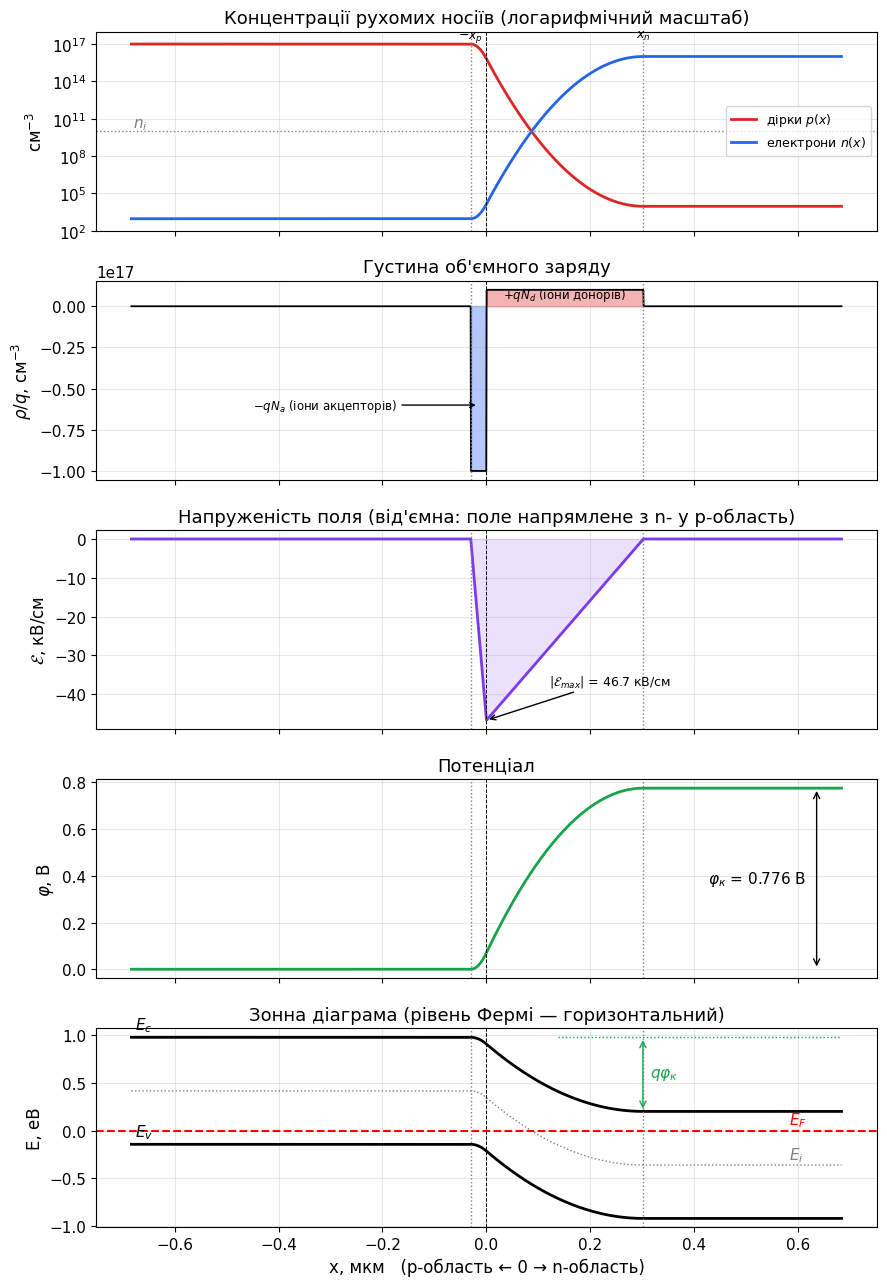

In [2]:
Na, Nd = 1e17, 1e16
j = pn_junction(Na, Nd)
x, phi = j['x'], j['phi']
pT = phi_T(300)
p = Na*np.exp(-phi/pT); n = Nd*np.exp(-(j['phik'] - phi)/pT)
Eg = 1.12; Ec_p = 0.0 + j['phik']                   # енергія відраховується від EF (EF = 0 у рівновазі)
EF_minus_Ev_p = pT*np.log(2.66e19/Na)                # Ev у p-області нижче EF на kT ln(Nv/Na)
Ev = -EF_minus_Ev_p - phi                            # Ev(x) = Ev(-inf) - q*phi(x)
Ec = Ev + Eg

fig, axes = plt.subplots(5, 1, figsize=(9, 13), sharex=True)
ax = axes[0]
ax.semilogy(x, p, color='#dc2626', label='дірки $p(x)$'); ax.semilogy(x, n, color='#2563eb', label='електрони $n(x)$')
ax.axhline(ni_Si, color='gray', ls=':', lw=1); ax.text(x[5], ni_Si*2, '$n_i$', color='gray')
ax.set_ylim(1e2, 1e18); ax.set_ylabel('см$^{-3}$'); ax.legend(fontsize=9, loc='center right')
ax.set_title('Концентрації рухомих носіїв (логарифмічний масштаб)')
ax = axes[1]
ax.fill_between(x, j['rho']/q, 0, where=j['rho'] < 0, color='#2563eb', alpha=0.35, step='mid')
ax.fill_between(x, j['rho']/q, 0, where=j['rho'] > 0, color='#dc2626', alpha=0.35, step='mid')
ax.plot(x, j['rho']/q, color='k', lw=1.3)
ax.annotate('$-qN_a$ (іони акцепторів)', xy=(-j['xp']/2, -Na*0.6), xytext=(-0.45, -Na*0.6), va='center', fontsize=8.5,
            arrowprops=dict(arrowstyle='->', lw=1))
ax.text(j['xn']/2, Nd*0.5, '$+qN_d$ (іони донорів)', ha='center', fontsize=8.5)
ax.set_ylabel(r'$\rho/q$, см$^{-3}$'); ax.set_title('Густина об\'ємного заряду')
ax = axes[2]
ax.plot(x, j['E']/1e3, color='#7c3aed'); ax.fill_between(x, j['E']/1e3, 0, color='#7c3aed', alpha=0.15)
ax.set_ylabel(r'$\mathcal{E}$, кВ/см'); ax.set_title('Напруженість поля (від\'ємна: поле напрямлене з n- у p-область)')
ax.annotate(f"$|\\mathcal{{E}}_{{max}}|$ = {j['Emax']/1e3:.1f} кВ/см", xy=(0, -j['Emax']/1e3), xytext=(0.12, -j['Emax']/1e3*0.8),
            arrowprops=dict(arrowstyle='->'), fontsize=9)
ax = axes[3]
ax.plot(x, phi, color='#16a34a'); ax.set_ylabel(r'$\varphi$, В')
ax.annotate('', xy=(x[-1]*0.93, j['phik']), xytext=(x[-1]*0.93, 0), arrowprops=dict(arrowstyle='<->'))
ax.text(x[-1]*0.9, j['phik']/2, f"$\\varphi_к$ = {j['phik']:.3f} В", ha='right', va='center')
ax.set_title('Потенціал')
ax = axes[4]
ax.plot(x, Ec, 'k', lw=2); ax.plot(x, Ev, 'k', lw=2)
ax.plot(x, Ev + Eg/2 + 0.5*pT*np.log(2.66/2.86), ':', color='gray', lw=1)
ax.axhline(0, color='r', ls='--', lw=1.5)
ax.text(x[10], Ec[10] + 0.08, '$E_c$'); ax.text(x[10], Ev[10] + 0.08, '$E_v$'); ax.text(x[-150], 0.06, '$E_F$', color='r')
ax.text(x[-150], Ev[-1] + Eg/2 + 0.06, '$E_i$', color='gray')
ax.annotate('', xy=(x[int(len(x)*0.72)], Ec[0]), xytext=(x[int(len(x)*0.72)], Ec[-1]), arrowprops=dict(arrowstyle='<->', color='#16a34a'))
ax.plot([x[int(len(x)*0.6)], x[-1]], [Ec[0], Ec[0]], ':', color='#16a34a', lw=1)
ax.text(x[int(len(x)*0.73)], (Ec[0] + Ec[-1])/2, r'$q\varphi_к$', color='#16a34a', va='center')
ax.set_ylabel('E, еВ'); ax.set_title('Зонна діаграма (рівень Фермі — горизонтальний)')
ax.set_xlabel('x, мкм   (p-область ← 0 → n-область)')
for a in axes:
    a.axvline(-j['xp'], color='gray', ls=':', lw=1); a.axvline(j['xn'], color='gray', ls=':', lw=1)
    a.axvline(0, color='k', ls='--', lw=0.7)
axes[0].text(-j['xp'], 3e17, '$-x_p$', ha='center', fontsize=9); axes[0].text(j['xn'], 3e17, '$x_n$', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## Ширина збідненого шару <a class="anchor" id="pn-width"></a>

З умови електронейтральності ОПЗ ($qN_ax_p = qN_dx_n$ — заряди обох частин рівні за модулем) і інтегрування рівняння Пуассона:

$$W = x_n + x_p = \sqrt{\frac{2\varepsilon}{q}\left(\frac{1}{N_a}+\frac{1}{N_d}\right)(\varphi_к - U)}, \qquad \frac{x_n}{x_p} = \frac{N_a}{N_d}.$$

Перехід поширюється переважно в **слабше леговану** область. У несиметричному $p^+$–$n$ переході $W \approx x_n \approx \sqrt{2\varepsilon(\varphi_к - U)/(qN_d)}$ — усі властивості переходу визначає слабко легована база. Типові значення для кремнію — від десятих часток мікрометра до десятків мікрометрів у високовольтних приладах.

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Контактна різниця потенціалів $\varphi_к$ **не вимірюється вольтметром**, підключеним до виводів діода, і не може бути джерелом струму. На контактах металевих виводів з p- і n-областями теж виникають контактні різниці потенціалів, і сума всіх стрибків потенціалу по замкненому колу в рівновазі дорівнює нулю. Інакше діод був би «вічним двигуном».

</div>

---

# p-n перехід під зовнішньою напругою <a class="anchor" id="pn-bias"></a>

Опір ОПЗ набагато більший за опір нейтральних областей, тому практично вся зовнішня напруга $U$ падає на переході, і напруга на ОПЗ дорівнює $\varphi_к - U$ (для прямої напруги $U > 0$ — «+» до p-області).

**Пряме зміщення** ($U > 0$). Бар'єр знижується до $\varphi_к - U$, ОПЗ звужується. Дифузійний потік основних носіїв через знижений бар'єр зростає як $e^{U/\varphi_T}$ — відбувається **інжекція**: дірки входять у n-область, електрони — у p-область, де вони стають надлишковими неосновними носіями й рекомбінують на відстані порядку дифузійної довжини. Концентрація неосновних носіїв на межах ОПЗ зростає за **законом переходу**:

$$p_n(x_n) = p_{n0}\,e^{U/\varphi_T}, \qquad n_p(-x_p) = n_{p0}\,e^{U/\varphi_T}.$$

**Зворотне зміщення** ($U < 0$). Бар'єр зростає до $\varphi_к + |U|$, ОПЗ розширюється ($W \propto \sqrt{\varphi_к + |U|}$). Дифузія основних носіїв практично припиняється, а поле переходу **екстрагує** неосновні носії, що з'являються біля ОПЗ внаслідок теплової генерації. Цей малий струм майже не залежить від напруги — це **тепловий струм** (струм насичення) $I_S$.

У нерівноважному стані єдиного рівня Фермі вже немає: концентрації електронів і дірок описують окремими **квазірівнями Фермі** $F_n$ і $F_p$, розщепленими в ОПЗ на $qU$: $F_n - F_p = qU$.

### 🔬 Інтерактивно: перехід при зміщенні — заряд, поле, зонна діаграма <a class="anchor" id="pn-bias-interactive"></a>

Змінюйте рівні легування і напругу. Штрихові лінії на зонній діаграмі — квазірівні Фермі $F_n$ (синій) і $F_p$ (червоний); у ОПЗ вони горизонтальні і розходяться на $qU$, а в нейтральних областях зливаються на відстані порядку дифузійної довжини (показано умовно). Для порівняння тонкими лініями зображено рівноважний стан.

In [3]:
def pn_bias(lgNa=17.0, lgNd=16.0, U=0.0):
    Na, Nd = 10**lgNa, 10**lgNd
    j0 = pn_junction(Na, Nd, 0.0)
    if U >= j0['phik'] - 0.05:
        print('Пряма напруга має бути меншою за φк (у реальному діоді її обмежує опір баз)'); return
    j = pn_junction(Na, Nd, U)
    L = max(abs(j0['x'][0]), 1.6*max(pn_junction(Na, Nd, -10)['xn'], pn_junction(Na, Nd, -10)['xp']))
    pT = phi_T(300); Eg = 1.12
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    for jj, st, lab in [(j0, ':', 'U = 0'), (j, '-', f'U = {U:+.2f} В')]:
        axes[0].plot(jj['x'], jj['rho']/q, st, color='k', lw=1.2 if st == ':' else 2, label=lab)
        axes[1].plot(jj['x'], jj['E']/1e3, st, color='#7c3aed', lw=1.2 if st == ':' else 2, label=lab)
    axes[0].set_title('Густина заряду $\\rho/q$, см$^{-3}$'); axes[0].legend(fontsize=9)
    axes[1].set_title('Напруженість поля, кВ/см'); axes[1].legend(fontsize=9)
    ax = axes[2]
    # Зонна діаграма: відлік енергії від F_p у p-області; n-область зміщена на -qU
    x, phi = j['x'], j['phi']
    Ev = -pT*np.log(2.66e19/Na) - phi
    ax.plot(x, Ev + Eg, 'k', lw=2); ax.plot(x, Ev, 'k', lw=2)
    # F_n - F_p = qU: при прямій напрузі F_n вище за F_p, при зворотній — нижче
    Fp = np.where(x < j['xn'], 0.0, U*(1 - np.exp(-(x - j['xn'])/(0.3*L))))       # квазірівень дірок
    Fn = np.where(x > -j['xp'], U, U*np.exp(-(-j['xp'] - x)/(0.3*L)))             # квазірівень електронів
    ax.plot(x, Fn, '--', color='#2563eb', lw=1.6, label='$F_n$')
    ax.plot(x, Fp, '--', color='#dc2626', lw=1.6, label='$F_p$')
    if abs(U) > 0.05:
        ax.annotate('', xy=(0, 0), xytext=(0, U), arrowprops=dict(arrowstyle='<->', color='#16a34a'))
        ax.text(0.03*L, U/2, f'$q|U|$ = {abs(U):.2f} еВ', color='#16a34a', fontsize=9)
    ax.set_title('Зонна діаграма і квазірівні Фермі'); ax.set_ylabel('E, еВ'); ax.legend(fontsize=9, loc='lower left')
    for a in axes:
        a.axvline(-j['xp'], color='gray', ls=':', lw=1); a.axvline(j['xn'], color='gray', ls=':', lw=1)
        a.set_xlim(-L, L); a.set_xlabel('x, мкм')
    plt.tight_layout(); plt.show()
    print(f"φк = {j0['phik']:.3f} В;  бар'єр φк − U = {j['Vj']:.3f} В;  W = {j['W']:.3f} мкм (при U = 0: {j0['W']:.3f} мкм);"
          f"  xn/xp = {j['xn']/j['xp']:.1f};  |E|max = {j['Emax']/1e3:.1f} кВ/см")

interact(pn_bias,
         lgNa=widgets.FloatSlider(min=15, max=19, step=0.5, value=17, description='lg $N_a$', continuous_update=False),
         lgNd=widgets.FloatSlider(min=15, max=19, step=0.5, value=16, description='lg $N_d$', continuous_update=False),
         U=widgets.FloatSlider(min=-10, max=0.7, step=0.05, value=-2.0, description='U, В', continuous_update=False));

interactive(children=(FloatSlider(value=17.0, continuous_update=False, description='lg $N_a$', max=19.0, min=1…

---
### ✅ Питання для самоперевірки: p-n перехід у рівновазі та при зміщенні

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому в рівноважному p-n переході струм дорівнює нулю, хоча через межу постійно рухаються носії?</summary>

> **Відповідь:** Бо для кожного типу носіїв дифузійний потік основних носіїв через бар'єр точно компенсується дрейфовим потоком неосновних носіїв, які поле переходу перекидає у зворотному напрямку. Це **динамічна** рівновага.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому ОПЗ ширша з боку слабше легованої області?</summary>

> **Відповідь:** Заряди обох частин ОПЗ рівні: $N_ax_p = N_dx_n$. Там, де концентрація іонів менша, для того самого заряду потрібен товщий шар.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як зміниться ширина ОПЗ кремнієвого переходу, якщо зворотну напругу збільшити з 0 до $3\varphi_к$?</summary>

> **Відповідь:** $W \propto \sqrt{\varphi_к + |U|}$, тому $W$ зросте в $\sqrt{4} = 2$ рази, а бар'єрна ємність зменшиться вдвічі.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Що таке квазірівні Фермі і чому вони розщеплюються при зміщенні?</summary>

> **Відповідь:** У нерівноважному стані концентрації електронів і дірок уже не описуються одним $E_F$: $n = n_ie^{(F_n - E_i)/kT}$, $p = n_ie^{(E_i - F_p)/kT}$. Зовнішнє джерело підтримує різницю електрохімічних потенціалів $F_n - F_p = qU$; при прямому зміщенні $np = n_i^2e^{U/\varphi_T} > n_i^2$ (інжекція), при зворотному — $np < n_i^2$ (екстракція).

</details>

---

# Ємності p-n переходу <a class="anchor" id="pn-capacitance"></a>

**Бар'єрна (зарядна) ємність.** При зміні напруги змінюється ширина ОПЗ, а отже, заряд нескомпенсованих іонів $Q = qN_dx_nS$. ОПЗ поводиться як плоский конденсатор з товщиною діелектрика $W$:

$$C_б = \frac{\varepsilon S}{W} = \frac{C_{б0}}{\left(1 - U/\varphi_к\right)^{m}}, \qquad m = \tfrac12 \text{ (різкий перехід)}, \quad m = \tfrac13 \text{ (плавний)}.$$

Саме цю формулу використовує SPICE (параметри `CJO` = $C_{б0}$, `VJ` = $\varphi_к$, `M` = $m$). Бар'єрна ємність домінує при зворотній напрузі; її використовують у **варикапах** — діодах, спеціально сконструйованих як керовані напругою конденсатори (гіперрізкий профіль легування дає $m \approx 0{,}5$–$2$ і великий коефіцієнт перекриття $C_{max}/C_{min}$).

**Дифузійна ємність.** При прямому зміщенні в базі накопичується заряд інжектованих неосновних носіїв $Q = \tau I$. Його зміна з напругою еквівалентна ємності

$$C_{диф} = \frac{dQ}{dU} = \frac{\tau I}{\varphi_T},$$

яка при прямих струмах в міліампери досягає сотень пікофарад і нанофарад (у SPICE — параметр `TT` = $\tau$). Дифузійна ємність обмежує швидкодію діода і транзистора при перемиканні з прямого стану у зворотний (Лекція 3).

### ⚙️ PySpice: вольт-фарадна характеристика діодів <a class="anchor" id="spice-cv"></a>

Ємність вимірюється так, як це роблять вимірювальні прилади (LCR-метри): на постійну напругу зміщення накладається малий змінний сигнал частотою 100 кГц, а ємність обчислюється з реактивної складової струму $C = \operatorname{Im}(I)/(2\pi f\,U_\sim)$. Порівнюються варикап **MV2201**, швидкий діод **1N4148** і випрямний **1N4007** (моделі з теки `models/`).

In [4]:
DIODES = {'MV2201 (варикап)': 'MV2201', '1N4148 (імпульсний)': 'D1N4148', '1N4007 (випрямний)': 'DI_1N4007'}

def measure_C(model, bias_list, f=1e5):
    """Мала-сигнальна ємність діода при зміщеннях bias_list (В; >0 — пряме)."""
    C = []
    for U in bias_list:
        c = Circuit('C-V')
        c.include(lib('diodes'))
        c.SinusoidalVoltageSource('s', 'a', c.gnd, dc_offset=U, ac_magnitude=1)
        c.D('1', 'a', c.gnd, model=model)
        an = c.simulator().ac(start_frequency=f, stop_frequency=f*10, number_of_points=1, variation='dec')
        I = complex(np.array(an.branches['vs'])[0])
        C.append(abs(I.imag)/(2*np.pi*f))
    return np.array(C)

def cv_plot(diode='MV2201 (варикап)', forward=False):
    m = DIODES[diode]
    U = np.linspace(-20, 0.7 if forward else 0, 90)
    C = measure_C(m, U)
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.semilogy(U, C*1e12, color='#2563eb')
    ax.set_xlabel('Напруга на діоді U, В (< 0 — зворотна)'); ax.set_ylabel('C, пФ')
    ax.set_title(f'Вольт-фарадна характеристика {diode} (ngspice, f = 100 кГц)')
    ax.grid(True, which='both', alpha=0.3)
    import matplotlib.ticker as mticker
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    few_decades = C.max()/C.min() < 30
    ax.yaxis.set_minor_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}' if few_decades else ''))
    if forward:
        ax.axvspan(0.3, 0.7, color='#fde68a', alpha=0.5); ax.text(0.32, C.max()/3, 'дифузійна\nємність', fontsize=9)
    plt.tight_layout(); plt.show()
    for u in [-1, -4, -10, -20]:
        k = np.argmin(abs(U - u)); print(f'C({u:+d} В) = {C[k]*1e12:6.2f} пФ', end='   ')
    print(f'\nКоефіцієнт перекриття C(-1 В)/C(-20 В) = {C[np.argmin(abs(U+1))]/C[0]:.2f}')

interact(cv_plot, diode=widgets.Dropdown(options=list(DIODES), description='Діод'),
         forward=widgets.Checkbox(value=False, description='показати пряму гілку (до +0,7 В)'));

interactive(children=(Dropdown(description='Діод', options=('MV2201 (варикап)', '1N4148 (імпульсний)', '1N4007…

### ⚙️ PySpice: коливальний контур, який перестроюється варикапом <a class="anchor" id="spice-varicap"></a>

Варикап MV2201 увімкнено в паралельний LC-контур ($L = 1$ мкГн) через розділовий конденсатор 1 нФ; постійну напругу керування $U_{кер}$ подано через резистор 100 кОм, який не шунтує контур. Змінюючи $U_{кер}$, перестроюємо резонансну частоту — так працюють генератори, керовані напругою (VCO), і вхідні контури радіоприймачів.

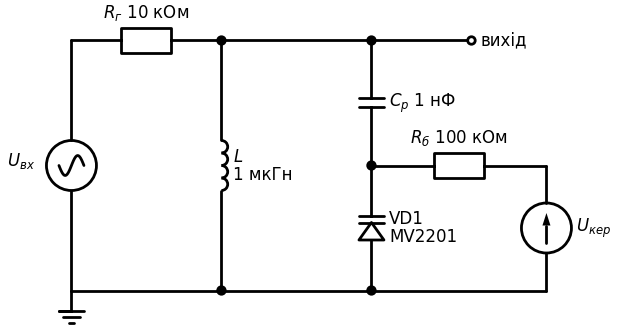

In [5]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.5) as d:
        H = 5.0                                                     # верхня шина; нижня (земля) — y = 0
        d.add(elm.SourceSin().endpoints((0, 0), (0, H)))
        d.add(elm.Label().at((-0.9, H/2)).label('$U_{вх}$'))
        d.add(elm.Resistor().endpoints((0, H), (3, H)).label('$R_г$ 10 кОм'))
        d.add(elm.Dot().at((3, H)))
        d.add(elm.Inductor().endpoints((3, H), (3, 0)).label('$L$\n1 мкГн', loc='bottom'))
        d.add(elm.Dot().at((3, 0)))
        d.add(elm.Line().endpoints((3, H), (6, H))); d.add(elm.Dot().at((6, H)))
        d.add(elm.Line().endpoints((6, H), (8, H))); d.add(elm.Dot(open=True).at((8, H)).label('вихід', loc='right'))
        d.add(elm.Capacitor().endpoints((6, H), (6, 2.5)).label('$C_р$ 1 нФ', loc='bottom'))
        d.add(elm.Dot().at((6, 2.5)))
        d.add(elm.Varactor().endpoints((6, 0), (6, 2.5)).label('VD1\nMV2201', loc='bottom'))  # анод — земля, катод — вгору
        d.add(elm.Dot().at((6, 0)))
        d.add(elm.Resistor().endpoints((6, 2.5), (9.5, 2.5)).label('$R_б$ 100 кОм'))
        d.add(EMF().endpoints((9.5, 0), (9.5, 2.5)).label('$U_{кер}$', loc='bottom'))   # стрілка — до «+»
        d.add(elm.Line().endpoints((0, 0), (9.5, 0)))
        d.add(elm.Ground().at((0, 0)))

In [6]:
def varicap_tank(U_ctrl=4.0):
    L = 1e-6
    c = Circuit('Varicap tuned tank')
    c.include(lib('diodes'))
    c.SinusoidalVoltageSource('in', 'in', c.gnd, ac_magnitude=1)
    c.R('g', 'in', 'tank', 10e3)
    c.L('1', 'tank', c.gnd, L)
    c.C('p', 'tank', 'k', 1e-9)                  # розділовий конденсатор
    c.D('1', c.gnd, 'k', model='MV2201')         # катод — до контуру, анод — на землі (зворотне зміщення)
    c.R('b', 'k', 'ctrl', 100e3)
    c.V('ctrl', 'ctrl', c.gnd, U_ctrl)
    an = c.simulator().ac(start_frequency=20e6, stop_frequency=150e6, number_of_points=2000, variation='lin')
    f = np.array(an.frequency); H = np.abs(np.array(an['tank']))
    f0 = f[np.argmax(H)]
    Cv = measure_C('MV2201', [-U_ctrl])[0]
    Ceq = 1/(1/Cv + 1/1e-9)
    f_theory = 1/(2*np.pi*np.sqrt(L*Ceq))
    fig, ax = plt.subplots(figsize=(8.5, 4.3))
    ax.plot(f/1e6, H, color='#7c3aed')
    ax.axvline(f_theory/1e6, color='gray', ls='--', lw=1)
    ax.set_xlabel('f, МГц'); ax.set_ylabel('$|U_{вих}/U_{вх}|$')
    ax.set_title(f'АЧХ контуру: $U_{{кер}}$ = {U_ctrl:.1f} В,  $f_0$ = {f0/1e6:.2f} МГц')
    plt.tight_layout(); plt.show()
    print(f'C варикапа = {Cv*1e12:.2f} пФ;  f0 (ngspice) = {f0/1e6:.2f} МГц;  f0 = 1/(2π√(LC)) = {f_theory/1e6:.2f} МГц')

interact(varicap_tank, U_ctrl=widgets.FloatSlider(min=0.5, max=20, step=0.5, value=4.0, description='$U_{кер}$, В',
                                                  continuous_update=False));

interactive(children=(FloatSlider(value=4.0, continuous_update=False, description='$U_{кер}$, В', max=20.0, mi…

---
### ⚡ Практичне застосування: Варикапи

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Варикапи застосовують для **електронного налаштування** контурів (тюнери радіо- і телеприймачів, синтезатори частоти з ФАПЧ, VCO в мобільних трансиверах), у **параметричних підсилювачах** і помножувачах частоти НВЧ. Перевага — відсутність механічних конденсаторів змінної ємності: налаштуванням керує цифро-аналоговий перетворювач мікроконтролера. Недолік — ємність залежить і від амплітуди сигналу, що спричиняє нелінійні спотворення, тому в контурах часто вмикають два варикапи зустрічно-послідовно.

</div>

---

# Контакт метал–напівпровідник <a class="anchor" id="ms-contact"></a>

Випрямні властивості має не лише p-n перехід, а й контакт металу з напівпровідником. Результат визначається співвідношенням **робіт виходу** металу $\Phi_M$ і напівпровідника $\Phi_S = \chi + (E_c - E_F)$, де $\chi$ — спорідненість до електрона (для Si $\chi = 4{,}05$ еВ).

- **Бар'єр Шотки** ($\Phi_M > \Phi_S$ для n-типу). Після контакту електрони переходять з напівпровідника в метал, доки рівні Фермі не вирівняються. У напівпровіднику біля межі утворюється збіднений шар іонів донорів, зони згинаються **вгору**. З боку металу електрони бачать бар'єр $q\varphi_B = \Phi_M - \chi$, з боку напівпровідника — $qV_{bi} = \Phi_M - \Phi_S$. Струм переносять **основні носії** (термоелектронна емісія через бар'єр), тому немає накопичення неосновних носіїв — діод Шотки дуже швидкий (Лекція 4).
- **Омічний контакт** — контакт з лінійною ВАХ і малим опором. Його отримують, сильно легуючи напівпровідник під металом ($N_d \gtrsim 10^{19}$ см⁻³): збіднений шар стає настільки тонким (одиниці нм), що електрони **тунелюють** крізь бар'єр в обох напрямках. Саме так виконують виводи всіх напівпровідникових приладів.

Реальні висоти бар'єрів часто відрізняються від $\Phi_M - \chi$ через поверхневі стани на межі розділу (ефект **закріплення рівня Фермі**): для n-Si типові $\varphi_B$ = 0,5–0,85 В.

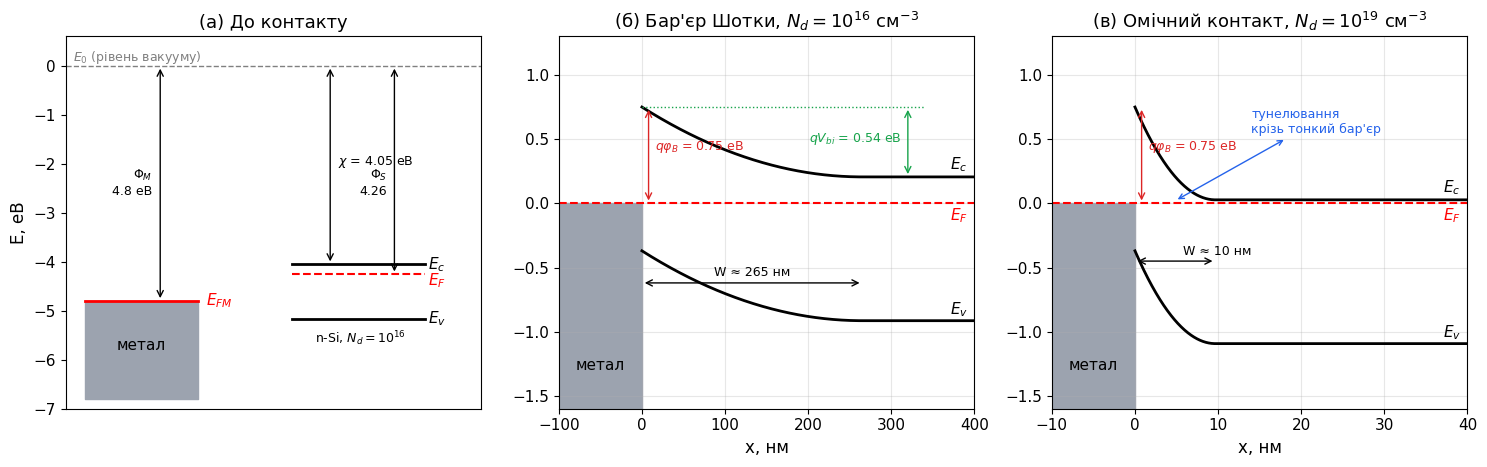

In [7]:
# Зонні діаграми контакту метал – n-Si: до контакту, бар'єр Шотки, омічний (тунельний) контакт
chi, Phi_M = 4.05, 4.80
Eg = 1.12
def ms_side(Nd):
    EcEF = phi_T(300)*np.log(2.86e19/Nd); Vbi = Phi_M - (chi + EcEF)
    W = np.sqrt(2*eps_Si*Vbi/(q*Nd))*1e7                                  # нм
    return EcEF, Vbi, W

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
# (а) до контакту: енергія від рівня вакууму E0 = 0
ax = axes[0]; EcEF, Vbi, W = ms_side(1e16)
ax.axhline(0, color='gray', ls='--', lw=1); ax.text(0.02, 0.1, '$E_0$ (рівень вакууму)', fontsize=9, color='gray')
ax.fill_between([0.05, 0.35], -Phi_M - 2, -Phi_M, color='#9ca3af'); ax.plot([0.05, 0.35], [-Phi_M]*2, 'r', lw=2)
ax.text(0.2, -Phi_M - 1, 'метал', ha='center'); ax.text(0.37, -Phi_M, '$E_{FM}$', color='r', va='center')
ax.annotate('', xy=(0.25, 0), xytext=(0.25, -Phi_M), arrowprops=dict(arrowstyle='<->'))
ax.text(0.23, -Phi_M/2, f'$\\Phi_M$\n{Phi_M} еВ', ha='right', va='center', fontsize=9)
Ec, EF = -chi, -chi - EcEF
ax.plot([0.6, 0.95], [Ec]*2, 'k', lw=2); ax.plot([0.6, 0.95], [Ec - Eg]*2, 'k', lw=2); ax.plot([0.6, 0.95], [EF]*2, 'r--', lw=1.5)
ax.text(0.96, Ec, '$E_c$', va='center'); ax.text(0.96, Ec - Eg, '$E_v$', va='center'); ax.text(0.96, EF - 0.12, '$E_F$', color='r', va='center')
ax.annotate('', xy=(0.7, 0), xytext=(0.7, Ec), arrowprops=dict(arrowstyle='<->')); ax.text(0.72, Ec/2, f'$\\chi$ = {chi} еВ', fontsize=9)
ax.annotate('', xy=(0.87, 0), xytext=(0.87, EF), arrowprops=dict(arrowstyle='<->')); ax.text(0.85, EF/2 - 0.5, f'$\\Phi_S$\n{chi+EcEF:.2f}', ha='right', fontsize=9)
ax.text(0.78, Ec - Eg - 0.5, 'n-Si, $N_d=10^{16}$', ha='center', fontsize=9)
ax.set_xlim(0, 1.1); ax.set_ylim(-7, 0.6); ax.set_xticks([]); ax.set_ylabel('E, еВ'); ax.set_title('(а) До контакту'); ax.grid(False)
# (б) і (в) після контакту: енергія від EF = 0
for ax, Nd, ttl in [(axes[1], 1e16, '(б) Бар\'єр Шотки, $N_d = 10^{16}$ см$^{-3}$'),
                    (axes[2], 1e19, '(в) Омічний контакт, $N_d = 10^{19}$ см$^{-3}$')]:
    EcEF, Vbi, W = ms_side(Nd)
    x = np.linspace(0, 400 if Nd < 1e18 else 40, 800)                   # нм
    Ec = EcEF + np.where(x < W, Vbi*(1 - x/W)**2, 0.0)
    ax.fill_between([-0.25*x[-1], 0], -1.6, 0, color='#9ca3af'); ax.axhline(0, color='r', ls='--', lw=1.5)
    ax.plot(x, Ec, 'k', lw=2); ax.plot(x, Ec - Eg, 'k', lw=2)
    ax.text(-0.125*x[-1], -1.3, 'метал', ha='center')
    ax.text(x[-1]*0.98, -0.13, '$E_F$', color='r', ha='right'); ax.text(x[-1]*0.98, Ec[-1] + 0.06, '$E_c$', ha='right')
    ax.text(x[-1]*0.98, Ec[-1] - Eg + 0.05, '$E_v$', ha='right')
    ax.annotate('', xy=(0.02*x[-1], Phi_M - chi), xytext=(0.02*x[-1], 0), arrowprops=dict(arrowstyle='<->', color='#dc2626'))
    ax.text(0.04*x[-1], (Phi_M - chi)*0.55, f'$q\\varphi_B$ = {Phi_M-chi:.2f} еВ', color='#dc2626', fontsize=9)
    if Nd < 1e18:
        ax.annotate('', xy=(0.8*x[-1], Ec[0]), xytext=(0.8*x[-1], Ec[-1]), arrowprops=dict(arrowstyle='<->', color='#16a34a'))
        ax.plot([0, 0.85*x[-1]], [Ec[0]]*2, ':', color='#16a34a', lw=1)
        ax.text(0.78*x[-1], (Ec[0] + Ec[-1])/2, f'$qV_{{bi}}$ = {Vbi:.2f} еВ', color='#16a34a', ha='right', fontsize=9)
        ax.annotate('', xy=(0, -0.62), xytext=(W, -0.62), arrowprops=dict(arrowstyle='<->', lw=1))
        ax.text(W/2, -0.57, f'W ≈ {W:.0f} нм', ha='center', fontsize=9)
    else:
        ax.annotate('тунелювання\nкрізь тонкий бар\'єр', xy=(W*0.5, 0.02), xytext=(0.35*x[-1], 0.55),
                    arrowprops=dict(arrowstyle='<->', color='#2563eb'), color='#2563eb', fontsize=9)
        ax.annotate('', xy=(0, -0.45), xytext=(W, -0.45), arrowprops=dict(arrowstyle='<->', lw=1))
        ax.text(W/2 + 1, -0.4, f'W ≈ {W:.0f} нм', fontsize=9)
    ax.set_xlim(-0.25*x[-1], x[-1]); ax.set_ylim(-1.6, 1.3); ax.set_xlabel('x, нм'); ax.set_title(ttl)
plt.tight_layout(); plt.show()

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Вальтер Шотки** (Walter Schottky) 1938 р. пояснив випрямлення на контакті метал–напівпровідник утворенням збідненого шару — за три роки до того, як у Bell Labs **Рассел Ол** (Russell Ohl, 1940) випадково виявив p-n перехід у кремнієвому злитку: освітлений зразок з тріщиною давав фото-ЕРС близько 0,5 В. Межа проходила там, де під час кристалізації домішки розподілились по-різному — саме Ол запропонував позначення «p» і «n».

</div>

---
### ✅ Питання для самоперевірки: Ємності та контакт метал–напівпровідник

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому бар'єрна ємність зменшується зі збільшенням зворотної напруги?</summary>

> **Відповідь:** Зі збільшенням $|U|$ розширюється ОПЗ: $W \propto \sqrt{\varphi_к + |U|}$. Ємність плоского конденсатора обернено пропорційна відстані між «обкладками», тому $C_б \propto (\varphi_к + |U|)^{-1/2}$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Яка ємність домінує при прямому зміщенні і від чого вона залежить?</summary>

> **Відповідь:** Дифузійна: $C_{диф} = \tau I/\varphi_T$ — пропорційна прямому струму і часу життя неосновних носіїв. При $I = 10$ мА і $\tau = 1$ мкс $C_{диф} \approx 0{,}39$ мкФ, що набагато більше за бар'єрну ємність.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чим принципово відрізняється перенесення струму в діоді Шотки від p-n діода?</summary>

> **Відповідь:** У діоді Шотки струм переносять основні носії (електрони з n-напівпровідника в метал, термоелектронна емісія), неосновні носії не інжектуються і не накопичуються. У p-n діоді прямий струм — це інжекція і дифузія неосновних носіїв, які накопичуються в базі і створюють дифузійну ємність.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чому для омічного контакту напівпровідник під металом сильно легують?</summary>

> **Відповідь:** При $N_d \gtrsim 10^{19}$ см⁻³ ширина збідненого шару $W \propto 1/\sqrt{N_d}$ стає одиниці нанометрів, і електрони вільно тунелюють крізь бар'єр в обох напрямках — ВАХ контакту стає лінійною з малим опором.

</details>

---
### 📝 Задачі для самостійного розв'язання: p-n перехід


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Кремнієвий різкий перехід: $N_a = 10^{17}$ см⁻³, $N_d = 10^{16}$ см⁻³, $T = 300$ К, $n_i = 9{,}65\cdot10^9$ см⁻³. Знайдіть контактну різницю потенціалів.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\varphi_к = \varphi_T\ln(N_aN_d/n_i^2) = 0{,}02585\cdot\ln\dfrac{10^{33}}{9{,}31\cdot10^{19}} = 0{,}776$ В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Для переходу з задачі 1 обчисліть ширину ОПЗ при $U = 0$, її частини $x_n$ і $x_p$ та максимальну напруженість поля ($\varepsilon = 11{,}7\varepsilon_0$).

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $W = \sqrt{\dfrac{2\varepsilon}{q}\left(\dfrac{1}{N_a}+\dfrac{1}{N_d}\right)\varphi_к} = 0{,}332$ мкм; $x_n = W\dfrac{N_a}{N_a+N_d} = 0{,}302$ мкм, $x_p = 0{,}030$ мкм; $|\mathcal{E}_{max}| = qN_dx_n/\varepsilon = 46{,}7$ кВ/см.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Яка бар'єрна ємність цього переходу площею 1 мм² при $U = 0$ і при зворотній напрузі 5 В?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $C_{б0} = \varepsilon S/W = 312$ пФ. При $U = -5$ В $W = 0{,}906$ мкм, $C_б = C_{б0}\sqrt{\varphi_к/(\varphi_к+5)} = 114$ пФ.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Варикап MV2201 має ємність 10,4 пФ при 1 В і 4,8 пФ при 10 В. У яких межах перестроюється контур з $L = 1$ мкГн?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $f = 1/(2\pi\sqrt{LC})$: від 49{,}3 МГц (1 В) до 72{,}6 МГц (10 В); коефіцієнт перекриття за частотою $\sqrt{10{,}4/4{,}8} \approx 1{,}47$.

</details>

---

## 📌 Підсумок лекції 2: Електронно-дірковий перехід <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Величина | Формула | Si, $N_a=10^{17}$, $N_d=10^{16}$ см⁻³ |
|---|---|---|
| Контактна різниця потенціалів | $\varphi_к = \varphi_T\ln(N_aN_d/n_i^2)$ | 0,78 В |
| Ширина ОПЗ | $W = \sqrt{\frac{2\varepsilon}{q}\left(\frac{1}{N_a}+\frac{1}{N_d}\right)(\varphi_к - U)}$ | 0,33 мкм |
| Розподіл ОПЗ | $x_n/x_p = N_a/N_d$ | 10 : 1 |
| Максимальне поле | $\mathcal{E}_{max} = qN_dx_n/\varepsilon$ | 47 кВ/см |
| Закон переходу | $p_n(x_n) = p_{n0}e^{U/\varphi_T}$ | — |
| Бар'єрна ємність | $C_б = C_{б0}(1 - U/\varphi_к)^{-m}$ | 31 нФ/см² |
| Дифузійна ємність | $C_{диф} = \tau I/\varphi_T$ | — |

**Головні висновки.** (1) Рівноважний p-n перехід — це динамічний баланс дифузії й дрейфу з потенціальним бар'єром $\varphi_к$. (2) Пряма напруга знижує бар'єр і експоненційно збільшує інжекцію неосновних носіїв; зворотна — підвищує бар'єр, і через перехід тече лише малий тепловий струм. У цьому полягає **однобічна провідність**, на якій ґрунтується діод. (3) Перехід має дві ємності: бар'єрну (варикап, обмеження ВЧ) і дифузійну (обмеження швидкості перемикання). (4) Контакт метал–напівпровідник може бути випрямним (Шотки) або омічним — залежно від робіт виходу й легування.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 1. Фізичні основи напівпровідників](Лекція_01_Фізичні_основи_напівпровідників.ipynb) &nbsp;|&nbsp; [Лекція 3. Вольт-амперна характеристика діода. Пробій і перехідні процеси](Лекція_03_Вольт-амперна_характеристика_діода.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*